#  SECTION 1 — Setup, Data Loading & Preprocessing

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

## 1.1  LOAD ALL 8 FILES AND COMBINE

In [5]:
file_paths = {
    'Monday_BENIGN'      : '/content/Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday'            : '/content/Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday'          : '/content/Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday_Morning'   : '/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday_Afternoon' : '/content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday_Morning'     : '/content/Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday_DDoS'        : '/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday_PortScan'    : '/content/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
}

# Quick verification
print("── File check ──")
for tag, path in file_paths.items():
    status = "✅" if os.path.exists(path) else "❌"
    print(f"{status} {tag}: {os.path.basename(path)}")

── File check ──
✅ Monday_BENIGN: Monday-WorkingHours.pcap_ISCX.csv
✅ Tuesday: Tuesday-WorkingHours.pcap_ISCX.csv
✅ Wednesday: Wednesday-workingHours.pcap_ISCX.csv
✅ Thursday_Morning: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
✅ Thursday_Afternoon: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
✅ Friday_Morning: Friday-WorkingHours-Morning.pcap_ISCX.csv
✅ Friday_DDoS: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
✅ Friday_PortScan: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


In [6]:
dfs = []
for tag, path in file_paths.items():
    try:
        df = pd.read_csv(path, low_memory=False)
        df['_source_file'] = tag
        dfs.append(df)
        print(f"✓ Loaded {tag}: {df.shape}")
    except FileNotFoundError:
        print(f"✗ NOT FOUND: {path}")

data = pd.concat(dfs, ignore_index=True)
print(f"\n✅ Combined dataset shape: {data.shape}")

✓ Loaded Monday_BENIGN: (529918, 80)
✓ Loaded Tuesday: (445909, 80)
✓ Loaded Wednesday: (692703, 80)
✓ Loaded Thursday_Morning: (170366, 80)
✓ Loaded Thursday_Afternoon: (288602, 80)
✓ Loaded Friday_Morning: (191033, 80)
✓ Loaded Friday_DDoS: (225745, 80)
✓ Loaded Friday_PortScan: (286467, 80)

✅ Combined dataset shape: (2830743, 80)


## 1.2  INITIAL EXPLORATION

In [7]:
print("\n── Column names ──")
print(data.columns.tolist())

print("\n── Label distribution (raw) ──")
print(data[' Label'].value_counts())

print("\n── Data types overview ──")
print(data.dtypes.value_counts())

print("\n── Missing values per column (top 20) ──")
print(data.isnull().sum().sort_values(ascending=False).head(20))


── Column names ──
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag

## 1.3  ATTACK CATEGORY MAPPING

In [8]:
# Map granular labels → broad attack category
attack_map = {
    'BENIGN'                      : 'BENIGN',
    'FTP-Patator'                 : 'Brute_Force',
    'SSH-Patator'                 : 'Brute_Force',
    'DoS Hulk'                    : 'DoS_DDoS',
    'DoS GoldenEye'               : 'DoS_DDoS',
    'DoS slowloris'               : 'DoS_DDoS',
    'DoS Slowhttptest'            : 'DoS_DDoS',
    'DDoS'                        : 'DoS_DDoS',
    'Heartbleed'                  : 'Web_Attack',
    'Web Attack \x96 Brute Force' : 'Web_Attack',
    'Web Attack \x96 XSS'         : 'Web_Attack',
    'Web Attack \x96 Sql Injection': 'Web_Attack',
    'Infiltration'                : 'Infiltration',
    'Bot'                         : 'Bot',
    'PortScan'                    : 'PortScan',
}
data[' Label'] = data[' Label'].str.strip()
data['Attack_Category'] = data[' Label'].map(attack_map).fillna('Other')
data['Binary_Label'] = (data['Attack_Category'] != 'BENIGN').astype(int)

print("\n── Attack category distribution ──")
print(data['Attack_Category'].value_counts())


── Attack category distribution ──
Attack_Category
BENIGN          2273097
DoS_DDoS         380688
PortScan         158930
Brute_Force       13835
Other              2180
Bot                1966
Infiltration         36
Web_Attack           11
Name: count, dtype: int64


## 1.4  PREPROCESSING

In [9]:
# Strip whitespace from column names
data.columns = data.columns.str.strip()

# Drop non-feature columns
drop_cols = ['Label', 'Attack_Category', 'Binary_Label', '_source_file']
feature_cols = [c for c in data.columns if c not in drop_cols]

# Convert all feature columns to numeric
for col in feature_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop columns with >50% missing or constant columns
missing_ratio = data[feature_cols].isnull().mean()
constant_cols = [c for c in feature_cols if data[c].nunique() <= 1]
drop_these    = list(missing_ratio[missing_ratio > 0.5].index) + constant_cols
feature_cols  = [c for c in feature_cols if c not in drop_these]
print(f"\nDropped {len(drop_these)} low-quality columns. Remaining features: {len(feature_cols)}")

# Fill remaining NaNs with median and replace inf values
data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)
data[feature_cols] = data[feature_cols].fillna(data[feature_cols].median())

# Save processed references for next sections
X_raw    = data[feature_cols].copy()
y_binary = data['Binary_Label'].copy()
y_multi  = data['Attack_Category'].copy()
label_raw = data['Label'].copy() if 'Label' in data.columns else data[' Label'].copy()

print(f"\n✅ Preprocessing complete. X shape: {X_raw.shape}")
print(f"   Binary class balance:\n{y_binary.value_counts()}")


Dropped 8 low-quality columns. Remaining features: 70

✅ Preprocessing complete. X shape: (2830743, 70)
   Binary class balance:
Binary_Label
0    2273097
1     557646
Name: count, dtype: int64


# SECTION 2 — Exploratory Data Analysis & Visualisations

## 2.1 Attack distribution bar chart

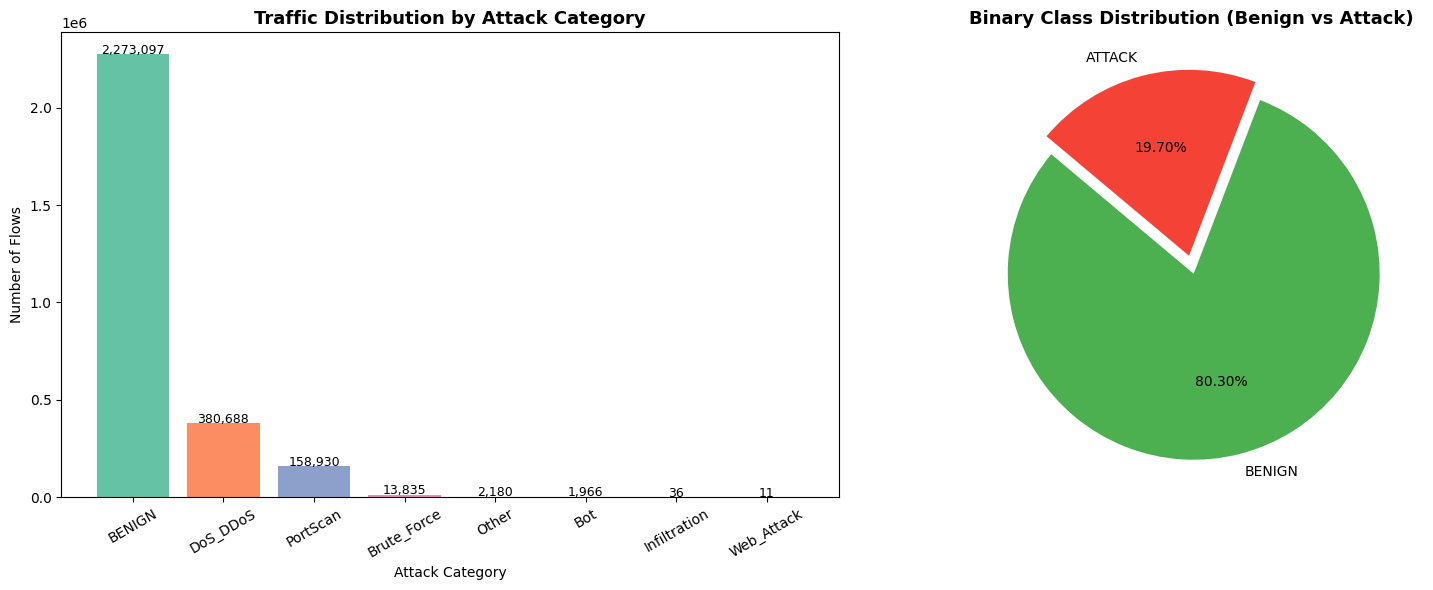

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_counts = data['Attack_Category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values,
            color=sns.color_palette('Set2', len(cat_counts)))
axes[0].set_title('Traffic Distribution by Attack Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontsize=9)

# Binary
binary_counts = y_binary.value_counts()
axes[1].pie(binary_counts.values,
            labels=['BENIGN', 'ATTACK'],
            autopct='%1.2f%%',
            startangle=140,
            colors=['#4CAF50', '#F44336'],
            explode=(0.05, 0.05))
axes[1].set_title('Binary Class Distribution (Benign vs Attack)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Correlation heatmap (top 20 features by variance)

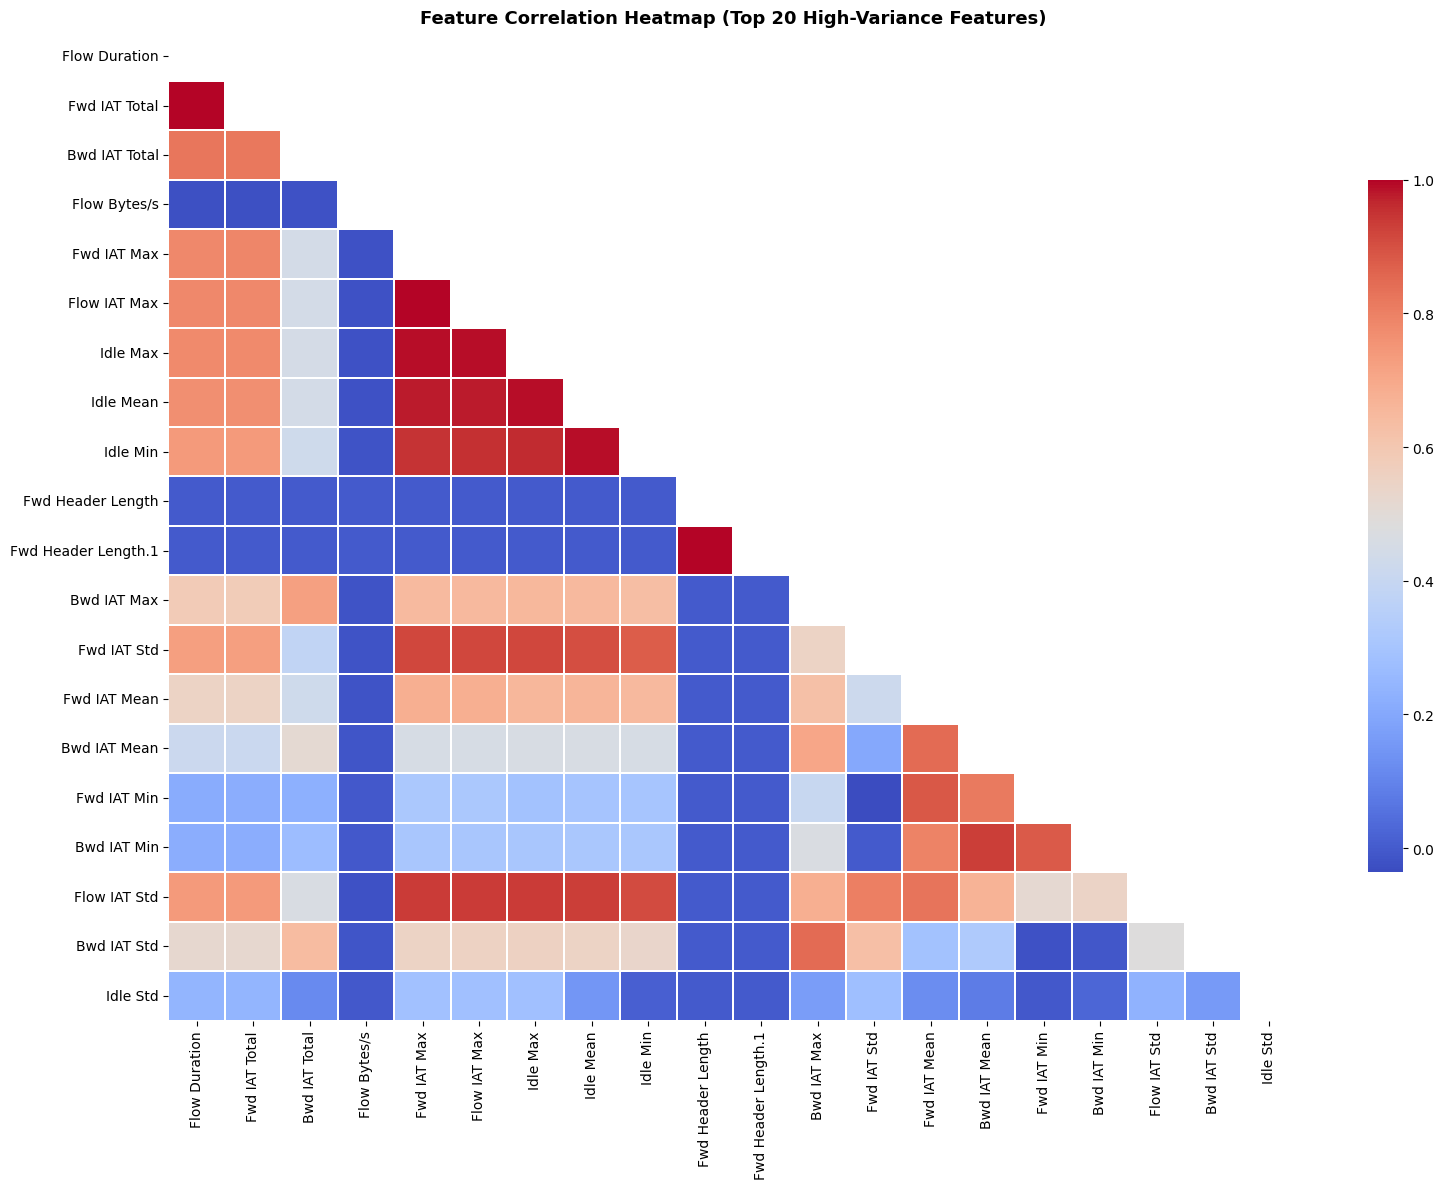

In [11]:
top_var_cols = X_raw.var().nlargest(20).index.tolist()
fig, ax = plt.subplots(figsize=(16, 12))
corr = X_raw[top_var_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Heatmap (Top 20 High-Variance Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Boxplots: key features per attack category

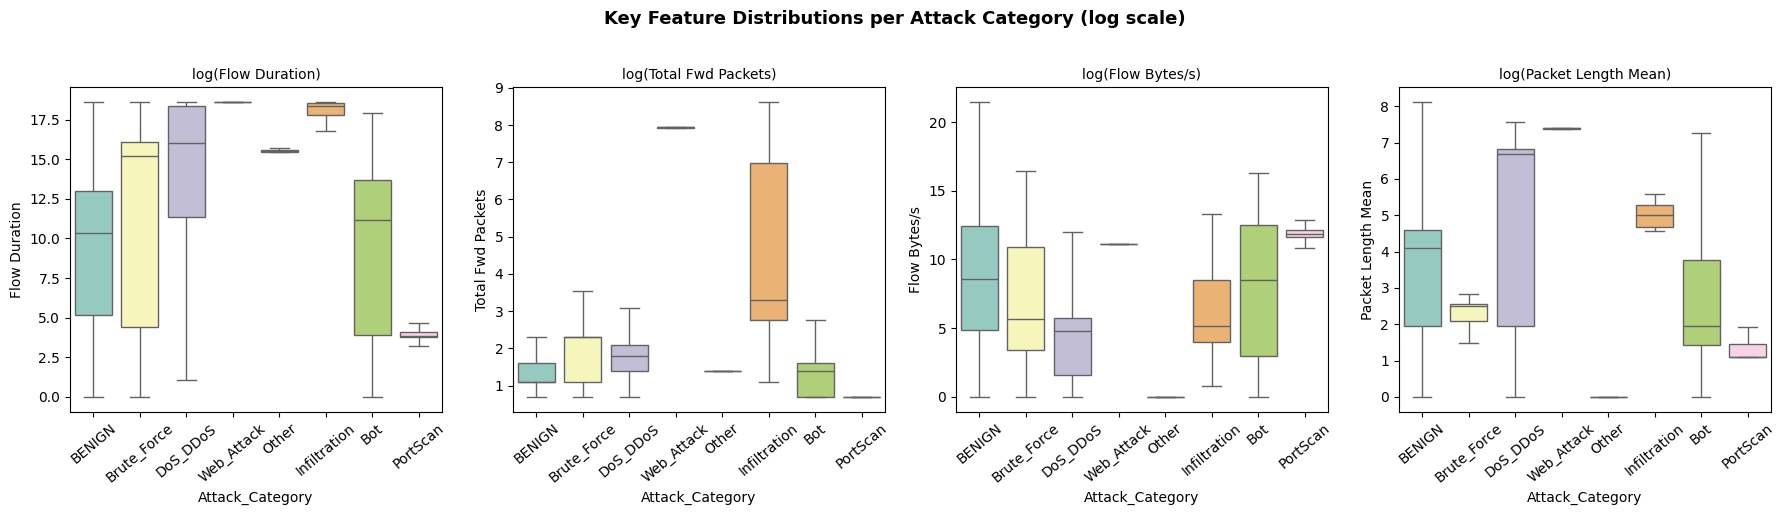

In [12]:
key_features = ['Flow Duration', 'Total Fwd Packets',
                'Flow Bytes/s', 'Packet Length Mean']
key_features = [f for f in key_features if f in X_raw.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 5))
for ax, feat in zip(axes, key_features):
    plot_df = data[['Attack_Category', feat]].copy()
    plot_df[feat] = np.log1p(plot_df[feat].clip(lower=0))
    sns.boxplot(data=plot_df, x='Attack_Category', y=feat, ax=ax,
                palette='Set3', showfliers=False)
    ax.set_title(f'log({feat})', fontsize=10)
    ax.tick_params(axis='x', rotation=40)
plt.suptitle('Key Feature Distributions per Attack Category (log scale)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Attack volume by day of week (source file proxy)

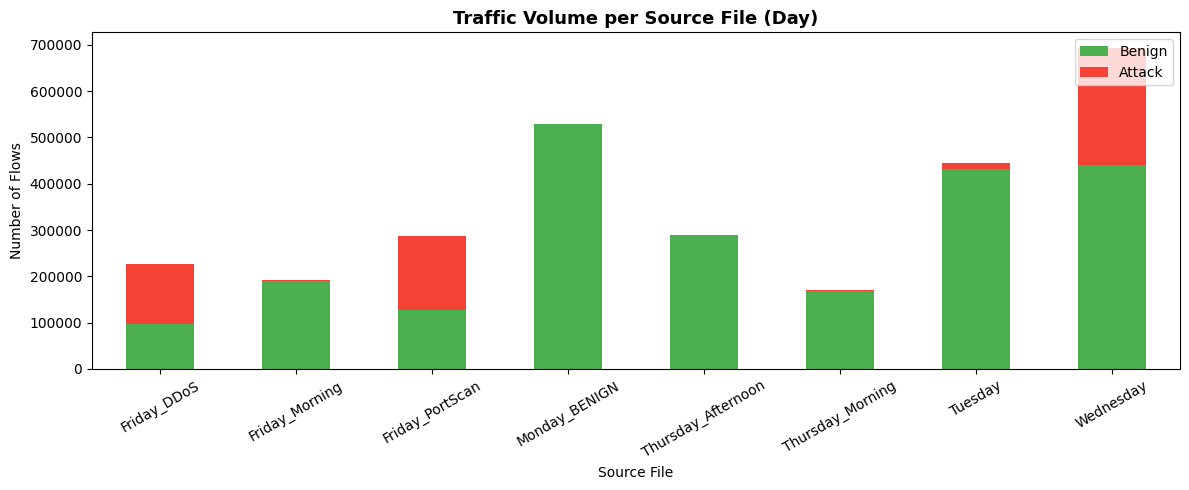

In [13]:
day_attack = data.groupby(['_source_file', 'Binary_Label']).size().unstack(fill_value=0)
day_attack.columns = ['Benign', 'Attack']
day_attack.plot(kind='bar', stacked=True, figsize=(12, 5),
                color=['#4CAF50', '#F44336'])
plt.title('Traffic Volume per Source File (Day)', fontsize=13, fontweight='bold')
plt.xlabel('Source File')
plt.ylabel('Number of Flows')
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig_daily_traffic.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.5 Feature importance via variance (quick pre-model analysis)

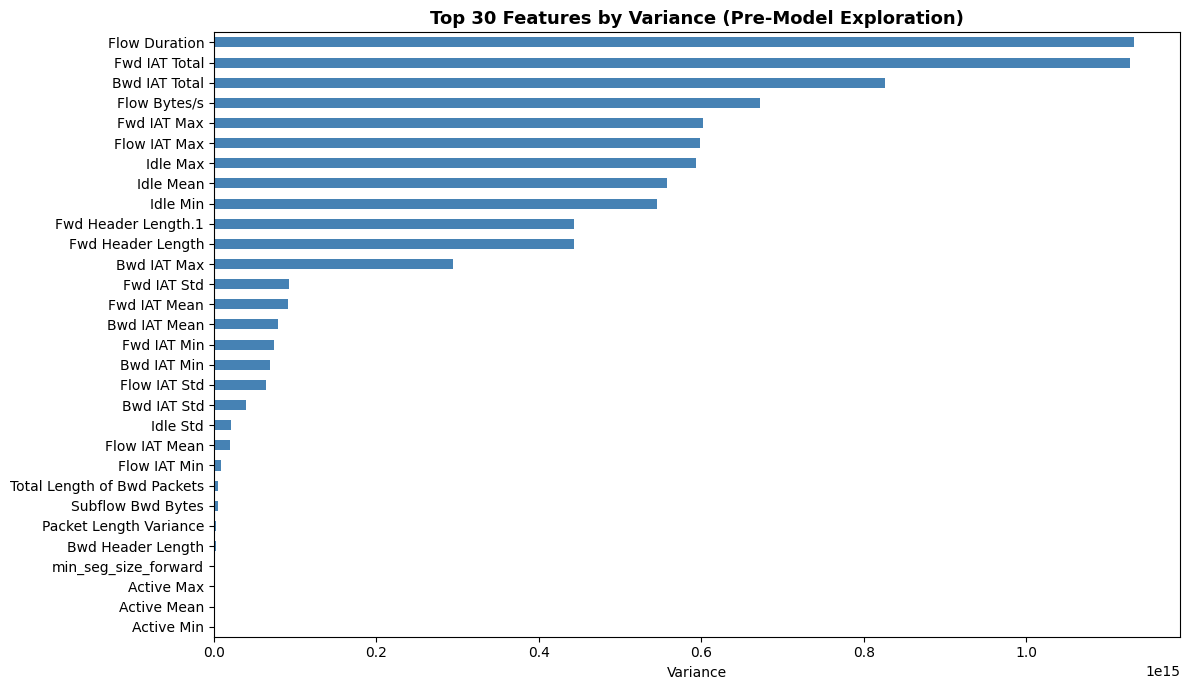

In [14]:
variance = X_raw.var().sort_values(ascending=False).head(30)
fig, ax = plt.subplots(figsize=(12, 7))
variance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 30 Features by Variance (Pre-Model Exploration)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Variance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 3 — Supervised Machine Learning Models

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, accuracy_score, average_precision_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import time

## 3.1 Sampling for computational feasibility

In [16]:
# Use stratified 20% sample to keep class balance
sample_frac = 0.20
X_sample, _, y_bin_sample, _, y_multi_sample, _ = train_test_split(
    X_raw, y_binary, y_multi,
    train_size=sample_frac,
    stratify=y_binary,
    random_state=42
)
print(f"Working sample size: {X_sample.shape}")
print(f"Binary balance:\n{y_bin_sample.value_counts()}")

Working sample size: (566148, 70)
Binary balance:
Binary_Label
0    454619
1    111529
Name: count, dtype: int64


## 3.2 Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_bin_sample,
    test_size=0.25, stratify=y_bin_sample, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 3.3 Handle Class Imbalance with SMOTE

In [18]:
print("\nApplying SMOTE for class imbalance...")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f"After SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")


Applying SMOTE for class imbalance...
After SMOTE: {0: 340964, 1: 340964}


## 3.4 Define Models

In [22]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=15,
                                                    n_jobs=-1, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, max_depth=6,
                                          learning_rate=0.1, use_label_encoder=False,
                                          eval_metric='logloss', n_jobs=-1,
                                          random_state=42),
}

In [23]:
results = {}
print("\n" + "="*60)
print("BINARY CLASSIFICATION RESULTS")
print("="*60)

for name, model in models.items():
    start = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_sc)

    # ROC AUC (needs predict_proba or decision_function)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_sc)[:, 1]
        roc = roc_auc_score(y_test, y_score)
        ap  = average_precision_score(y_test, y_score)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_sc)
        roc = roc_auc_score(y_test, y_score)
        ap  = average_precision_score(y_test, y_score)
    else:
        y_score = y_pred
        roc = roc_auc_score(y_test, y_pred)
        ap  = 0.0

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'Accuracy': round(acc, 4),
        'F1 (weighted)': round(f1, 4),
        'ROC-AUC': round(roc, 4),
        'Avg Precision': round(ap, 4),
        'Train Time (s)': round(elapsed, 2),
        'y_score': y_score,
        'y_pred': y_pred,
    }

    print(f"\n── {name} ──")
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  F1 (weighted): {f1:.4f}")
    print(f"  ROC-AUC:       {roc:.4f}")
    print(f"  Train time:    {elapsed:.2f}s")
    print(classification_report(y_test, y_pred, target_names=['BENIGN','ATTACK']))


BINARY CLASSIFICATION RESULTS

── Logistic Regression ──
  Accuracy:      0.9153
  F1 (weighted): 0.9198
  ROC-AUC:       0.9785
  Train time:    73.03s
              precision    recall  f1-score   support

      BENIGN       0.99      0.90      0.94    113655
      ATTACK       0.71      0.96      0.82     27882

    accuracy                           0.92    141537
   macro avg       0.85      0.93      0.88    141537
weighted avg       0.94      0.92      0.92    141537


── Decision Tree ──
  Accuracy:      0.9944
  F1 (weighted): 0.9945
  ROC-AUC:       0.9984
  Train time:    27.39s
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00    113655
      ATTACK       0.97      1.00      0.99     27882

    accuracy                           0.99    141537
   macro avg       0.99      1.00      0.99    141537
weighted avg       0.99      0.99      0.99    141537


── Random Forest ──
  Accuracy:      0.9983
  F1 (weighted): 0.9983
  ROC-

## 3.5 Summary Table

In [25]:
metric_keys = ['Accuracy','F1 (weighted)','ROC-AUC','Avg Precision','Train Time (s)']
summary = pd.DataFrame({k: {m: results[k][m] for m in metric_keys} for k in results}).T
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary.to_string())


SUMMARY TABLE
                     Accuracy  F1 (weighted)  ROC-AUC  Avg Precision  Train Time (s)
Logistic Regression    0.9153         0.9198   0.9785         0.9154           73.03
Decision Tree          0.9944         0.9945   0.9984         0.9888           27.39
Random Forest          0.9983         0.9983   0.9999         0.9996          266.59
XGBoost                0.9986         0.9986   0.9999         0.9997           21.32


## 3.6 ROC Curve Comparison

✅ Logistic Regression → AUC: 0.9785
✅ Decision Tree → AUC: 0.9984
✅ Random Forest → AUC: 0.9999
✅ XGBoost → AUC: 0.9999


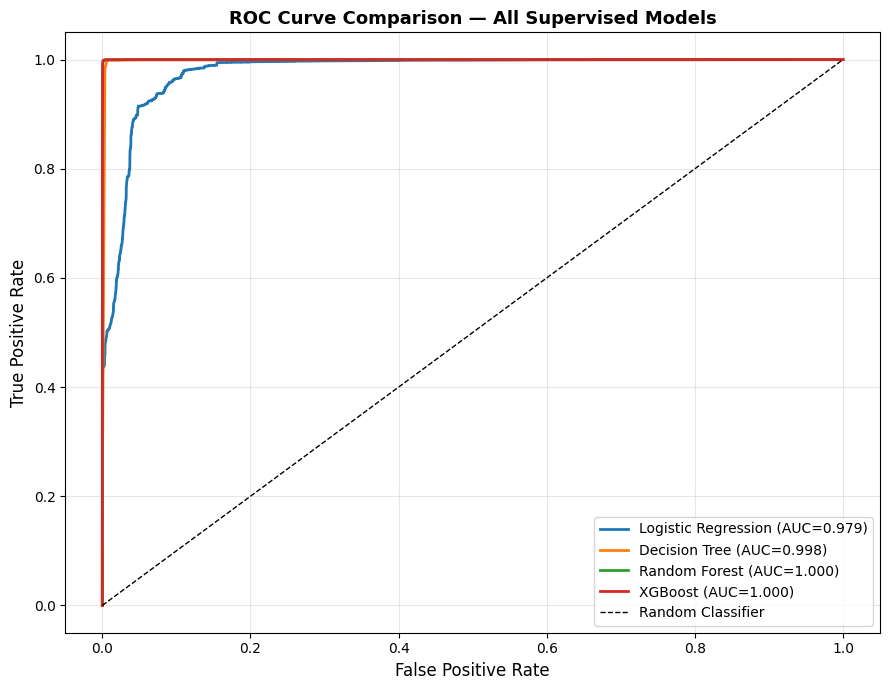

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_data = {}
for name, res in results.items():
    y_score = res['y_score']
    fpr_c, tpr_c, _ = roc_curve(y_test, y_score)
    auc_val = roc_auc_score(y_test, y_score)
    roc_data[name] = (fpr_c, tpr_c, round(auc_val, 4))
    print(f"✅ {name} → AUC: {auc_val:.4f}")

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
fig, ax = plt.subplots(figsize=(9, 7))
for (name, (fpr_c, tpr_c, auc_val)), col in zip(roc_data.items(), colors):
    ax.plot(fpr_c, tpr_c, label=f"{name} (AUC={auc_val:.3f})", color=col, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison — All Supervised Models',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Performance Bar Chart

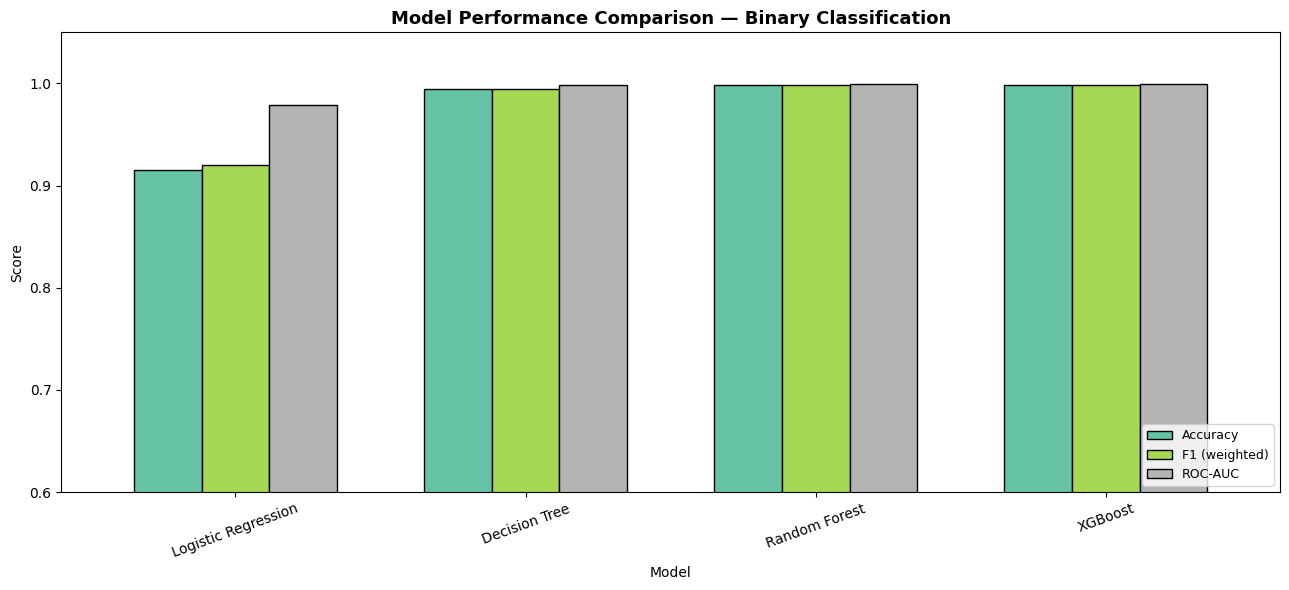

In [30]:
plot_metrics = ['Accuracy', 'F1 (weighted)', 'ROC-AUC']
summary[plot_metrics].astype(float).plot(
    kind='bar', figsize=(13, 6),
    colormap='Set2', edgecolor='black', width=0.7
)
plt.title('Model Performance Comparison — Binary Classification',
          fontsize=13, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0.6, 1.05)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig_model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.8 Confusion Matrices

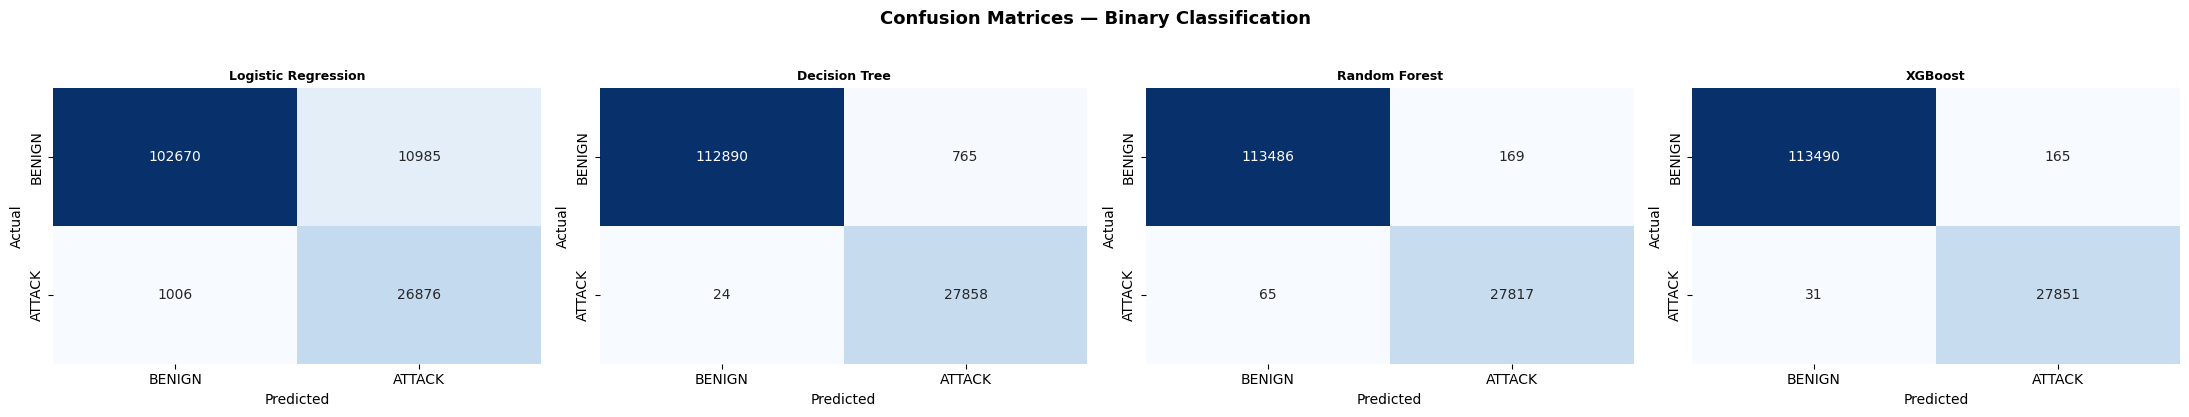

In [31]:
fig, axes = plt.subplots(1, len(models), figsize=(22, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['BENIGN','ATTACK'],
                yticklabels=['BENIGN','ATTACK'], cbar=False)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Binary Classification',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 4 — Multiclass Attack Classification

In [32]:
from sklearn.preprocessing import LabelEncoder
from collections import Counter

## 4.1 Encode multiclass labels

In [33]:
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi_sample)
class_names  = le.classes_
print("Classes:", class_names)

Classes: ['BENIGN' 'Bot' 'Brute_Force' 'DoS_DDoS' 'Infiltration' 'Other' 'PortScan']


In [34]:
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_sample, y_multi_enc,
    test_size=0.25, stratify=y_multi_enc, random_state=42
)

scaler_m   = StandardScaler()
X_tr_m_sc  = scaler_m.fit_transform(X_tr_m)
X_te_m_sc  = scaler_m.transform(X_te_m)

In [35]:
# SMOTE (use safe k_neighbors)
min_count  = min(Counter(y_tr_m).values())
k_nb       = max(1, min(3, min_count - 1))
smote_m    = SMOTE(random_state=42, k_neighbors=k_nb)
X_tr_m_sm, y_tr_m_sm = smote_m.fit_resample(X_tr_m_sc, y_tr_m)
print(f"After SMOTE (multiclass): {dict(zip(*np.unique(y_tr_m_sm, return_counts=True)))}")

After SMOTE (multiclass): {np.int64(0): np.int64(340964), np.int64(1): np.int64(340964), np.int64(2): np.int64(340964), np.int64(3): np.int64(340964), np.int64(4): np.int64(340964), np.int64(5): np.int64(340964), np.int64(6): np.int64(340964)}


## 4.2 Train 2-Models

In [36]:
multi_models = {
    'Decision Tree' : DecisionTreeClassifier(max_depth=12, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, max_depth=15,
                                              n_jobs=-1, random_state=42)
}

In [37]:
multi_results = {}
print("\n" + "="*60)
print("MULTICLASS CLASSIFICATION RESULTS")
print("="*60)

for name, model in multi_models.items():
    model.fit(X_tr_m_sm, y_tr_m_sm)
    y_pred_m = model.predict(X_te_m_sc)
    acc = accuracy_score(y_te_m, y_pred_m)
    f1  = f1_score(y_te_m, y_pred_m, average='weighted', zero_division=0)
    multi_results[name] = {'Accuracy': acc, 'F1': f1, 'y_pred': y_pred_m}
    print(f"\n── {name} (Acc={acc:.4f} | F1={f1:.4f}) ──")
    print(classification_report(y_te_m, y_pred_m,
                                 target_names=class_names, zero_division=0))


MULTICLASS CLASSIFICATION RESULTS

── Decision Tree (Acc=0.9885 | F1=0.9908) ──
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    113655
         Bot       0.11      0.95      0.19        95
 Brute_Force       0.91      1.00      0.95       683
    DoS_DDoS       0.97      1.00      0.98     19044
Infiltration       0.00      0.00      0.00         1
       Other       0.45      0.97      0.61       112
    PortScan       0.99      1.00      1.00      7947

    accuracy                           0.99    141537
   macro avg       0.63      0.84      0.68    141537
weighted avg       0.99      0.99      0.99    141537


── Random Forest (Acc=0.9937 | F1=0.9956) ──
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      1.00    113655
         Bot       0.12      0.95      0.21        95
 Brute_Force       1.00      1.00      1.00       683
    DoS_DDoS       0.99      1.00      1.00     19044
Infil

KeyboardInterrupt: 

## 4.3 Confusion Matrix — best model


Best multiclass model: Random Forest


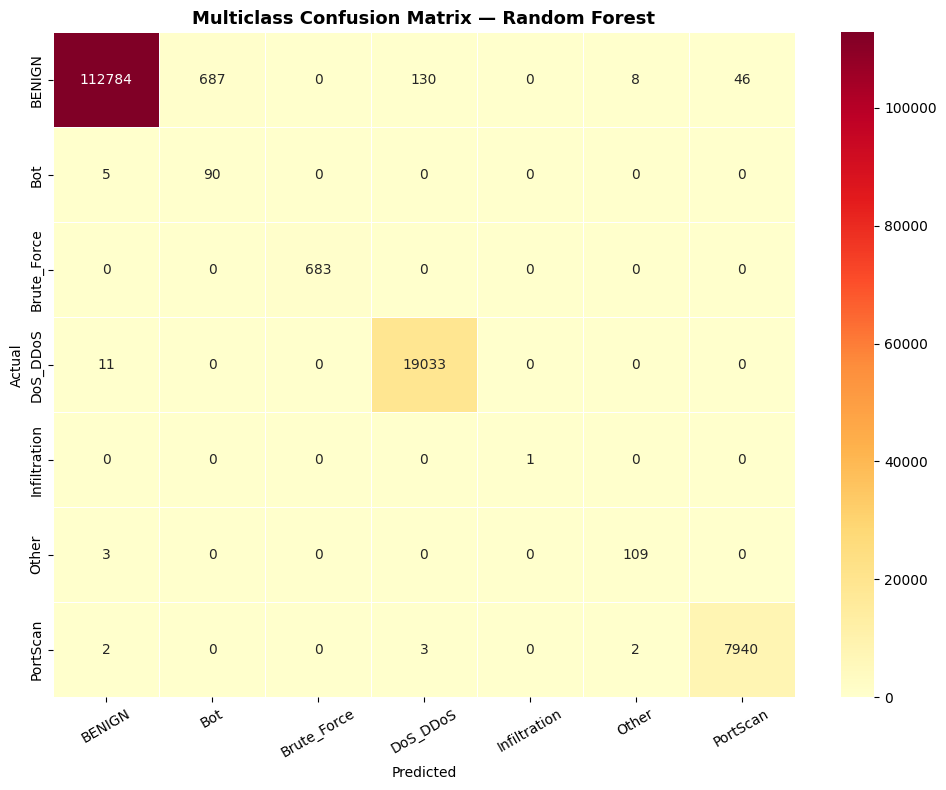

In [38]:
best_name    = max(multi_results, key=lambda k: multi_results[k]['F1'])
y_pred_best  = multi_results[best_name]['y_pred']
print(f"\nBest multiclass model: {best_name}")

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_te_m, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title(f'Multiclass Confusion Matrix — {best_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_multiclass_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Per-class F1 bar chart

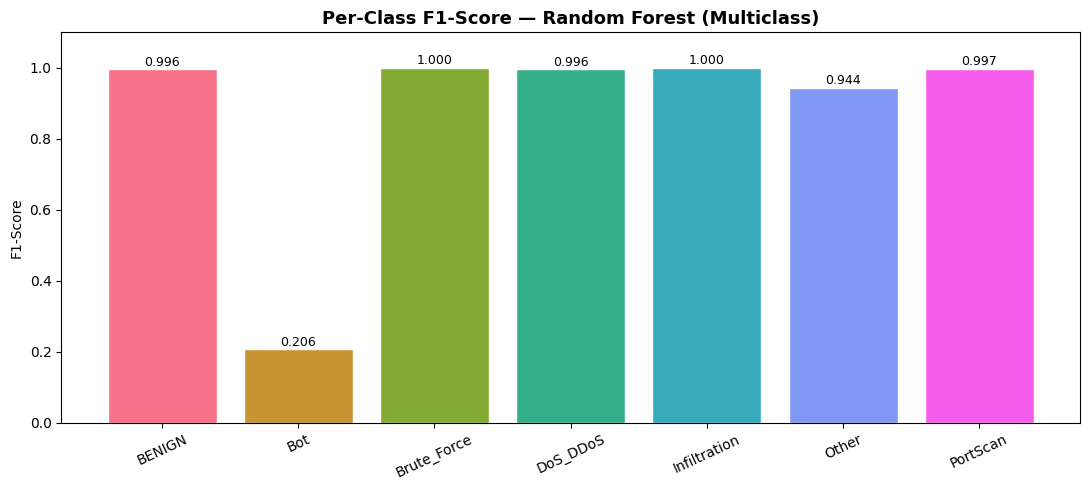

In [39]:
from sklearn.metrics import classification_report as cr
report = cr(y_te_m, y_pred_best, target_names=class_names,
            output_dict=True, zero_division=0)
per_class_f1 = {cls: report[cls]['f1-score'] for cls in class_names}

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(per_class_f1.keys(), per_class_f1.values(),
              color=sns.color_palette('husl', len(class_names)),
              edgecolor='white')
ax.set_title(f'Per-Class F1-Score — {best_name} (Multiclass)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=25)
for bar, val in zip(bars, per_class_f1.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Multiclass model comparison


Multiclass Summary:
               Accuracy  F1 (weighted)
Decision Tree  0.988519       0.990806
Random Forest  0.993662       0.995566


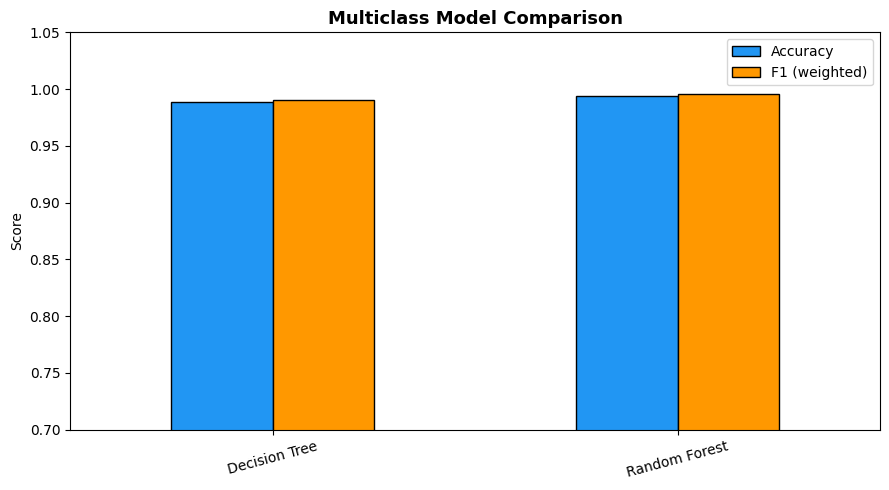

In [40]:
mc_summary = pd.DataFrame({k: {'Accuracy': v['Accuracy'], 'F1 (weighted)': v['F1']}
                            for k, v in multi_results.items()}).T
print("\nMulticlass Summary:")
print(mc_summary.to_string())
mc_summary.astype(float).plot(kind='bar', figsize=(9, 5),
                               color=['#2196F3','#FF9800'], edgecolor='black')
plt.title('Multiclass Model Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('fig_multiclass_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 5 — Unsupervised Anomaly Detection

In [41]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, roc_curve)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)

## 5.1 Prepare data: train on BENIGN only

In [42]:
benign_mask = y_binary == 0

X_benign_full = X_raw[benign_mask.values]
X_benign      = X_benign_full.sample(n=min(30000, len(X_benign_full)), random_state=42)

X_all_us = X_raw.sample(n=min(60000, len(X_raw)), random_state=42)
y_all_us = y_binary.loc[X_all_us.index].values

scaler_us    = StandardScaler()
X_benign_sc  = scaler_us.fit_transform(X_benign)
X_all_sc     = scaler_us.transform(X_all_us)

print(f"Benign training samples : {X_benign_sc.shape[0]:,}")
print(f"Total test samples      : {X_all_sc.shape[0]:,}")
print(f"Attack ratio in test    : {y_all_us.mean():.3%}")

unsup_results = {}

Benign training samples : 30,000
Total test samples      : 60,000
Attack ratio in test    : 19.790%


## 5.2 Isolation Forest

In [45]:
print("\n[1/3] Training Isolation Forest...")
iso = IsolationForest(n_estimators=200, contamination=0.15,
                       max_samples='auto', random_state=42, n_jobs=-1)
iso.fit(X_benign_sc)

iso_scores = -iso.score_samples(X_all_sc)
iso_preds  = (iso.predict(X_all_sc) == -1).astype(int)

unsup_results['Isolation Forest'] = {
    'ROC-AUC'  : round(roc_auc_score(y_all_us, iso_scores), 4),
    'F1'       : round(f1_score(y_all_us, iso_preds, zero_division=0), 4),
    'Precision': round(precision_score(y_all_us, iso_preds, zero_division=0), 4),
    'Recall'   : round(recall_score(y_all_us, iso_preds, zero_division=0), 4),
    'scores'   : iso_scores,
    'preds'    : iso_preds,
}
print(f"  ✅ ROC-AUC: {unsup_results['Isolation Forest']['ROC-AUC']} | "
      f"F1: {unsup_results['Isolation Forest']['F1']}")


[1/3] Training Isolation Forest...
  ✅ ROC-AUC: 0.7497 | F1: 0.4473


## 5.3 K-Means

In [46]:
print("\n[2/3] Training K-Means (k=7)...")
kmeans = MiniBatchKMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X_benign_sc)

km_dist  = np.min(
    np.linalg.norm(X_all_sc[:, None, :] - kmeans.cluster_centers_[None, :, :], axis=2),
    axis=1
)
thresh_km = np.percentile(km_dist, 85)
km_preds  = (km_dist > thresh_km).astype(int)

unsup_results['K-Means'] = {
    'ROC-AUC'  : round(roc_auc_score(y_all_us, km_dist), 4),
    'F1'       : round(f1_score(y_all_us, km_preds, zero_division=0), 4),
    'Precision': round(precision_score(y_all_us, km_preds, zero_division=0), 4),
    'Recall'   : round(recall_score(y_all_us, km_preds, zero_division=0), 4),
    'scores'   : km_dist,
    'preds'    : km_preds,
}
print(f"  ✅ ROC-AUC: {unsup_results['K-Means']['ROC-AUC']} | "
      f"F1: {unsup_results['K-Means']['F1']}")


[2/3] Training K-Means (k=7)...
  ✅ ROC-AUC: 0.7968 | F1: 0.5281


## 5.4 Autoencoder

In [47]:
print("\n[3/3] Training Autoencoder...")

def build_autoencoder(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dense(32, activation='relu')(x)   # bottleneck
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    ae  = models.Model(inp, out)
    ae.compile(optimizer='adam', loss='mse')
    return ae

ae = build_autoencoder(X_benign_sc.shape[1])
ae.summary()



[3/3] Training Autoencoder...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 70)             │         9,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,398 (153.90 KB)

 Trainable params: 39,142 (152.90 KB)

 Non-trainable params: 256 (1.00 KB)

In [48]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=1)
history = ae.fit(
    X_benign_sc, X_benign_sc,
    epochs=50, batch_size=256,
    validation_split=0.1,
    callbacks=[es], verbose=1
)

Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.6354 - val_loss: 0.3956
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3333 - val_loss: 0.2649
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1894 - val_loss: 0.3551
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1976 - val_loss: 0.2909
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1592 - val_loss: 0.2129
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1234 - val_loss: 0.1390
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1079 - val_loss: 0.1548
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0958 - val_loss: 0.2564
Epoch 9/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1304 - val_loss: 0.3273
Epoch 10/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0869 - val_loss: 0.2030
Epoch 11/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0810 - val_loss: 0.1495
Epoch 11: early stopping
Restoring model weights f

In [49]:
ae_recon  = ae.predict(X_all_sc, verbose=0)
ae_scores = np.mean(np.square(X_all_sc - ae_recon), axis=1)
thresh_ae = np.percentile(ae_scores, 85)
ae_preds  = (ae_scores > thresh_ae).astype(int)

In [50]:
unsup_results['Autoencoder'] = {
    'ROC-AUC'  : round(roc_auc_score(y_all_us, ae_scores), 4),
    'F1'       : round(f1_score(y_all_us, ae_preds, zero_division=0), 4),
    'Precision': round(precision_score(y_all_us, ae_preds, zero_division=0), 4),
    'Recall'   : round(recall_score(y_all_us, ae_preds, zero_division=0), 4),
    'scores'   : ae_scores,
    'preds'    : ae_preds,
}
print(f"\n  ✅ ROC-AUC: {unsup_results['Autoencoder']['ROC-AUC']} | "
      f"F1: {unsup_results['Autoencoder']['F1']}")


  ✅ ROC-AUC: 0.8598 | F1: 0.5453


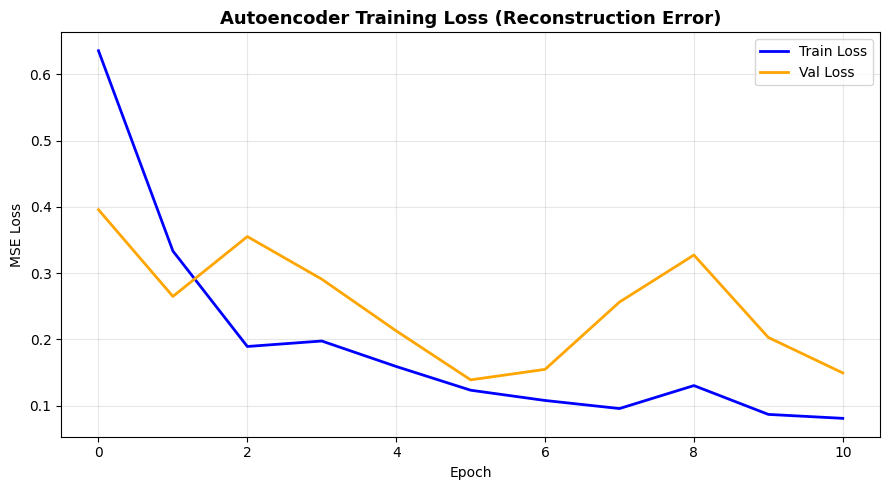

✅ Autoencoder loss saved.


In [51]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['loss'],     label='Train Loss', lw=2, color='blue')
ax.plot(history.history['val_loss'], label='Val Loss',   lw=2, color='orange')
ax.set_title('Autoencoder Training Loss (Reconstruction Error)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_autoencoder_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Autoencoder loss saved.")

## 5.5 Anomaly Score Distributions

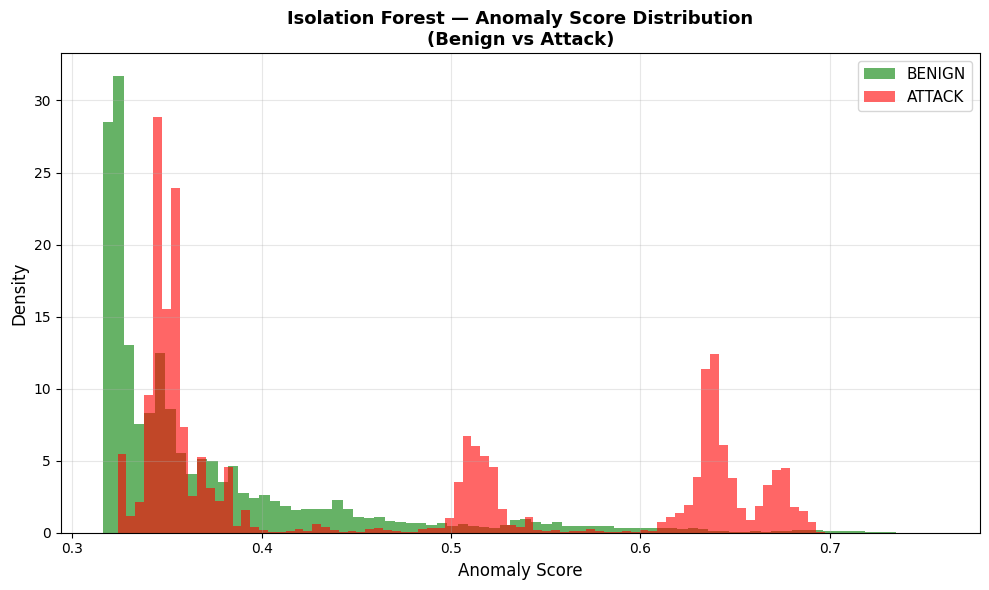

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))

sc    = unsup_results['Isolation Forest']['scores']
y_ref = y_all_us
n     = min(len(sc), len(y_ref))

ax.hist(sc[:n][y_ref[:n] == 0], bins=80, alpha=0.6,
        color='green', label='BENIGN', density=True)
ax.hist(sc[:n][y_ref[:n] == 1], bins=80, alpha=0.6,
        color='red', label='ATTACK', density=True)

ax.set_title('Isolation Forest — Anomaly Score Distribution\n(Benign vs Attack)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Anomaly Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_anomaly_scores_iforest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 ROC Curves — Unsupervised

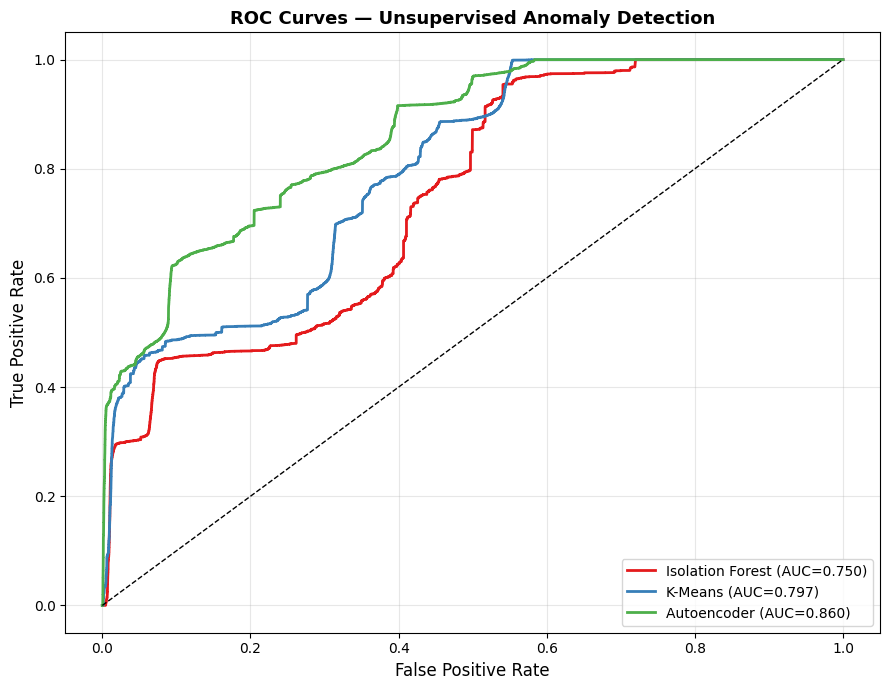

In [57]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_us = ['#e41a1c','#377eb8','#4daf4a','#984ea3']
ref_map = {
    'Isolation Forest': y_all_us,
    'K-Means'         : y_all_us,
    'Autoencoder'     : y_all_us,
}
for (name, res), col in zip(unsup_results.items(), colors_us):
    y_ref_us = ref_map[name]
    sc       = res['scores']
    n        = min(len(sc), len(y_ref_us))
    fpr_u, tpr_u, _ = roc_curve(y_ref_us[:n], sc[:n])
    ax.plot(fpr_u, tpr_u, lw=2, color=col,
            label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Unsupervised Anomaly Detection',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_unsupervised_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.7 PCA 2D Visualization


Generating PCA scatter...


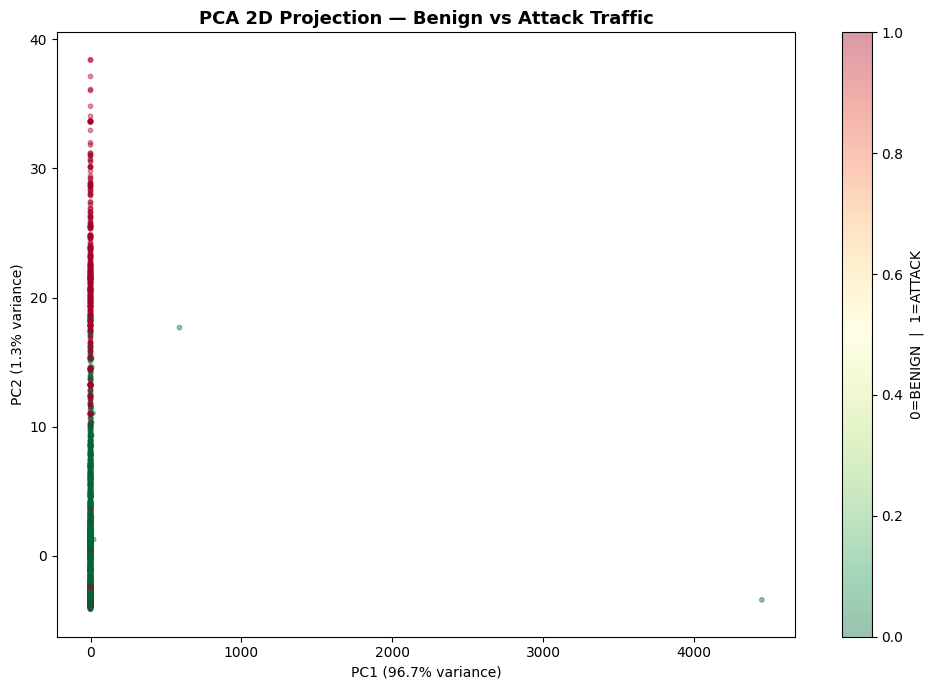

In [58]:
print("\nGenerating PCA scatter...")
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_sc[:5000])
y_pca = y_all_us[:5000]

fig, ax = plt.subplots(figsize=(10, 7))
sc_plot = ax.scatter(X_pca[:,0], X_pca[:,1],
                     c=y_pca, cmap='RdYlGn_r',
                     alpha=0.4, s=10, vmin=0, vmax=1)
plt.colorbar(sc_plot, ax=ax, label='0=BENIGN  |  1=ATTACK')
ax.set_title('PCA 2D Projection — Benign vs Attack Traffic',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.savefig('fig_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.8 Unsupervised Summary

In [59]:
unsup_summary = pd.DataFrame(
    {k: {m: v for m, v in d.items() if m not in ('scores','preds')}
     for k, d in unsup_results.items()}
).T
print("\n── Unsupervised Anomaly Detection Summary ──")
print(unsup_summary.to_string())


── Unsupervised Anomaly Detection Summary ──
                  ROC-AUC      F1  Precision  Recall
Isolation Forest   0.7497  0.4473     0.4328  0.4628
K-Means            0.7968  0.5281     0.6124  0.4642
Autoencoder        0.8598  0.5453     0.6323  0.4793


In [62]:
print("\n── False Positive & False Negative Rate Analysis ──")
fpr_results = {}
for name, res in results.items():
    cm_r = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm_r.ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0
    fpr_results[name] = {
        'FP': fp, 'FN': fn,
        'FPR (False Alarm)': round(fpr_val, 4),
        'FNR (Miss Rate)'  : round(fnr_val, 4)
    }
    print(f"{name:22s} → FPR: {fpr_val:.4f} | FNR: {fnr_val:.4f} | FP: {fp} | FN: {fn}")


── False Positive & False Negative Rate Analysis ──
Logistic Regression    → FPR: 0.0967 | FNR: 0.0361 | FP: 10985 | FN: 1006
Decision Tree          → FPR: 0.0067 | FNR: 0.0009 | FP: 765 | FN: 24
Random Forest          → FPR: 0.0015 | FNR: 0.0023 | FP: 169 | FN: 65
XGBoost                → FPR: 0.0015 | FNR: 0.0011 | FP: 165 | FN: 31


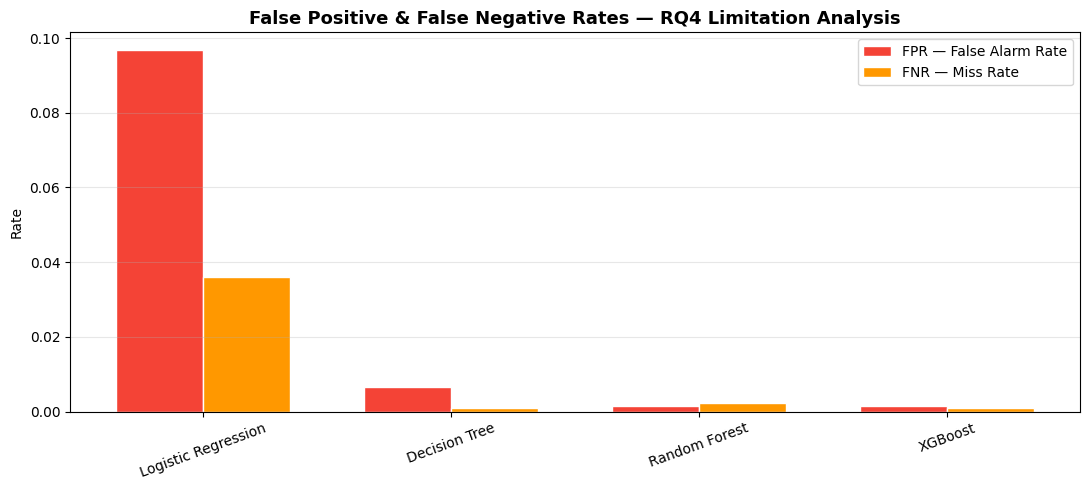

In [63]:
fpr_df = pd.DataFrame(fpr_results).T
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(fpr_df))
w = 0.35
ax.bar(x - w/2, fpr_df['FPR (False Alarm)'].astype(float), w,
       label='FPR — False Alarm Rate', color='#F44336', edgecolor='white')
ax.bar(x + w/2, fpr_df['FNR (Miss Rate)'].astype(float),   w,
       label='FNR — Miss Rate',        color='#FF9800', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(fpr_df.index, rotation=20)
ax.set_title('False Positive & False Negative Rates — RQ4 Limitation Analysis',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Rate')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_fpr_fnr.png', dpi=150, bbox_inches='tight')
plt.show()

In [65]:
print("\n" + "="*65)
print("FINAL SUPERVISED RESULTS")
print("="*65)
print(summary[['Accuracy','F1 (weighted)',
               'ROC-AUC','Avg Precision','Train Time (s)']].to_string())

print("\n" + "="*65)
print("FINAL UNSUPERVISED RESULTS")
print("="*65)
print(unsup_summary.to_string())


FINAL SUPERVISED RESULTS
                     Accuracy  F1 (weighted)  ROC-AUC  Avg Precision  Train Time (s)
Logistic Regression    0.9153         0.9198   0.9785         0.9154           73.03
Decision Tree          0.9944         0.9945   0.9984         0.9888           27.39
Random Forest          0.9983         0.9983   0.9999         0.9996          266.59
XGBoost                0.9986         0.9986   0.9999         0.9997           21.32

FINAL UNSUPERVISED RESULTS
                  ROC-AUC      F1  Precision  Recall
Isolation Forest   0.7497  0.4473     0.4328  0.4628
K-Means            0.7968  0.5281     0.6124  0.4642
Autoencoder        0.8598  0.5453     0.6323  0.4793
